### importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Step 1: Load Sample Safe City Dataset (Simulated)
data = {
    "Camera_ID": np.arange(1, 101),
    "Crime_Rate": np.random.randint(0, 10, 100),
    "Traffic_Density": np.random.randint(1, 100, 100),
    "Facial_Recognition_Hits": np.random.randint(0, 5, 100),
    "Emergency_Response_Time": np.random.randint(5, 30, 100),
    "Incident_Reported": np.random.choice([0, 1], size=100)  # 0 = No Incident, 1 = Incident Reported
}
df = pd.DataFrame(data)
print(df.head())

   Camera_ID  Crime_Rate  Traffic_Density  Facial_Recognition_Hits  \
0          1           8               45                        1   
1          2           9               26                        0   
2          3           5                1                        2   
3          4           8               83                        2   
4          5           6               96                        1   

   Emergency_Response_Time  Incident_Reported  
0                       20                  0  
1                       29                  1  
2                        6                  0  
3                       10                  0  
4                        8                  0  


In [3]:
# Step 2: Data Cleaning
# Check for missing values
df.fillna(df.median(), inplace=True)

In [4]:
# Step 3: Data Preprocessing
X = df.drop("Incident_Reported", axis=1)
y = df["Incident_Reported"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Step 4: Apply Random Forest model
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [7]:
# Step 5: Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.40
Confusion Matrix:
 [[6 4]
 [8 2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.60      0.50        10
           1       0.33      0.20      0.25        10

    accuracy                           0.40        20
   macro avg       0.38      0.40      0.38        20
weighted avg       0.38      0.40      0.38        20



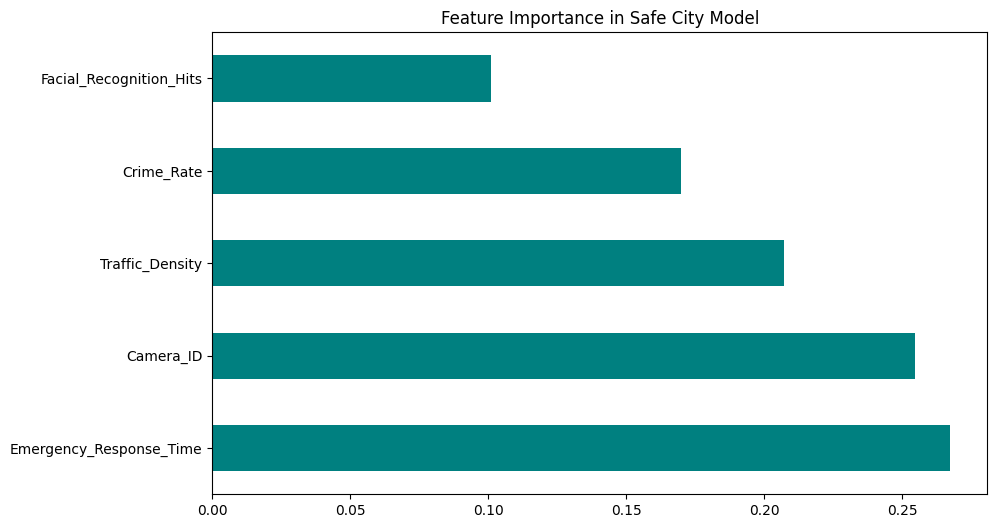

In [8]:
# Step 6: Data Visualization
# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title("Feature Importance in Safe City Model")
plt.show()

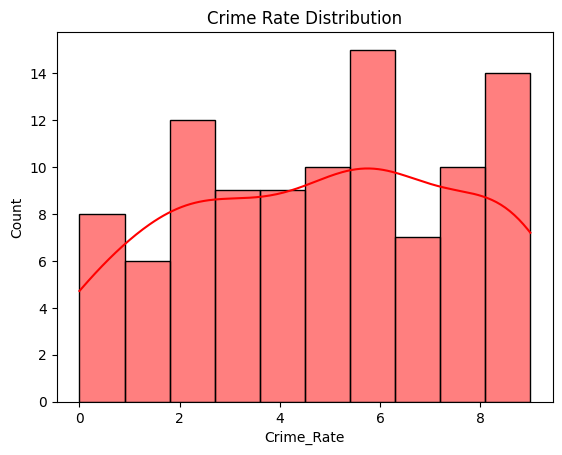

In [9]:
# Plot crime rate distribution
sns.histplot(df['Crime_Rate'], bins=10, kde=True, color='red')
plt.title("Crime Rate Distribution")
plt.show()

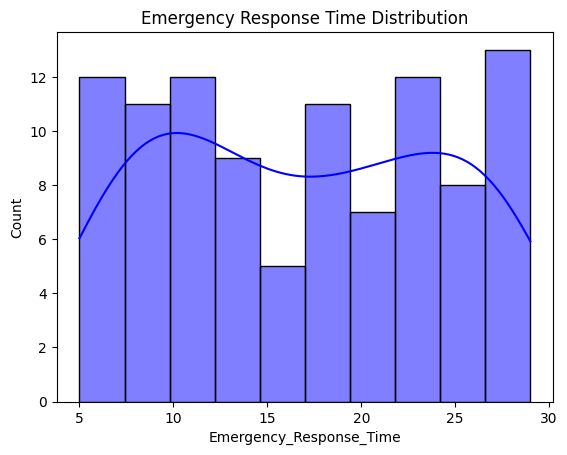

In [10]:
# Plot emergency response time
sns.histplot(df['Emergency_Response_Time'], bins=10, kde=True, color='blue')
plt.title("Emergency Response Time Distribution")
plt.show()